In [1]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

In [10]:
mkdir -p ~/.kaggle && echo KGAT_784fb46f22c044618e6778d5bd6a7107 > ~/.kaggle/access_token && chmod 600 ~/.kaggle/access_token

In [ ]:
%pip install kaggle --upgrade
!kaggle datasets download -d msambare/fer2013
!unzip -o fer2013.zip

In [ ]:
!unzip fer2013.zip -d /content/

In [20]:
train_dir = "/content/train"
test_dir = "/content/test"

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

In [4]:
test_datagen = ImageDataGenerator(
    rescale=1./255
)

In [18]:
import os
print(os.listdir('/content'))

['.config', 'fer2013.zip', 'test', 'train', 'sample_data']


In [19]:
!find /content -type d | grep train

/content/train
/content/train/surprise
/content/train/happy
/content/train/fear
/content/train/angry
/content/train/sad
/content/train/disgust
/content/train/neutral


In [21]:
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical'
)

validation_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 28709 images belonging to 7 classes.
Found 7178 images belonging to 7 classes.


In [22]:
model = Sequential([

    Input(shape=(48,48,1)),

    Conv2D(32,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128,(3,3),activation='relu'),
    BatchNormalization(),
    MaxPooling2D(),

    Flatten(),

    Dense(256,activation='relu'),
    Dropout(0.5),

    Dense(7,activation='softmax')
])

In [23]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)

In [25]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stop]
)

Epoch 1/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 37s 33ms/step - accuracy: 0.2726 - loss: 1.8292 - val_accuracy: 0.3835 - val_loss: 1.5942
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.3419 - loss: 1.6450 - val_accuracy: 0.3802 - val_loss: 1.5937
Epoch 3/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 25s 28ms/step - accuracy: 0.3886 - loss: 1.5560 - val_accuracy: 0.3860 - val_loss: 1.5117
Epoch 4/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.4149 - loss: 1.4918 - val_accuracy: 0.4774 - val_loss: 1.3421
Epoch 5/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.4331 - loss: 1.4633 - val_accuracy: 0.4104 - val_loss: 1.5469
Epoch 6/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.4483 - loss: 1.4281 - val_accuracy: 0.4455 - val_loss: 1.4832
Epoch 7/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 25s 27ms/step - accuracy: 0.4633 - loss: 1.3991 - val_accuracy: 0.4756 - val_loss: 1.3694
Epoch 8/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 24s 27ms/step - accuracy: 0.4733 - loss: 1.3823 - 

In [26]:
model.save("emotion_model_v2.keras")

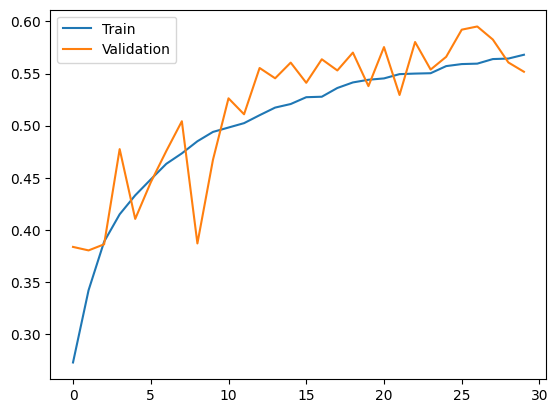

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train','Validation'])
plt.show()

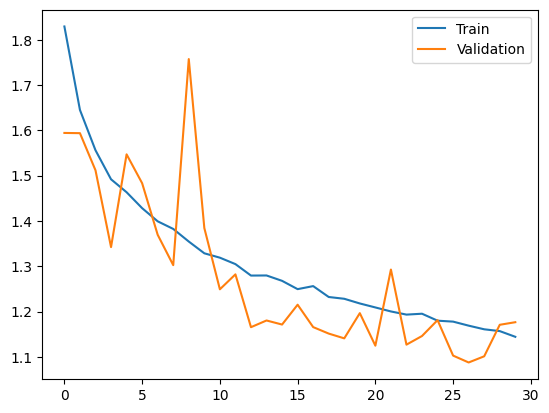

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train','Validation'])
plt.show()